##car-dekho dataset from vois site

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [8]:
df.shape

(301, 9)

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [9]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [15]:
#data quality check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows: ',duplicate_count)

Duplicate Rows:  0


In [14]:
df = df.drop_duplicates().copy()
print('Duplicates Remaining: ',df.duplicated().sum())

Duplicates Remaining:  0


In [17]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [18]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [19]:
print("Fuel Type:")
print(df['Fuel_Type'].value_counts())

print("\nSeller Type:")
print(df['Seller_Type'].value_counts())

print("\nTransmission:")
print(df['Transmission'].value_counts())

print("\nOwner:")
print(df['Owner'].value_counts())


Fuel Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller Type:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Owner:
Owner
0    288
1     10
3      1
Name: count, dtype: int64


In [33]:
df['Depreciation_%'] = (
    (df['Present_Price'] - df['Selling_Price'])
    / df['Present_Price']
) * 100
df[['Car_Name', 'Present_Price', 'Selling_Price', 'Depreciation_%']] \
    .sort_values('Depreciation_%', ascending=False)

,Car_Name,Present_Price,Selling_Price,Depreciation_%
85,camry,23.73,2.50,89.464812
77,corolla,12.35,1.50,87.854251
200,Bajaj Pulsar 150,0.75,0.10,86.666667
37,800,2.28,0.35,84.649123
94,corolla altis,22.78,4.00,82.440737
...,...,...,...,...
235,verna,9.40,9.10,3.191489
208,i20,8.10,7.90,2.469136
231,verna,9.40,9.25,1.595745
8,ciaz,8.89,8.75,1.574803


In [34]:
df['Brand'] = df['Car_Name'].str.split().str[0]
brand_depreciation = (
    df.groupby('Brand')['Depreciation_%']
    .mean()
    .sort_values(ascending=False)
)

brand_depreciation

,Depreciation_%
Brand,
camry,89.464812
800,84.649123
land,62.203024
sx4,61.414729
Hyosung,60.869565
corolla,60.248724
Suzuki,56.896552
omni,53.531599
ritz,46.495651


In [36]:
df['Car_Age'] = 2026 - df['Year']
df[['Year', 'Car_Age']].drop_duplicates().sort_values('Year')

,Year,Car_Age
37,2003,23
77,2004,22
54,2005,21
47,2006,20
192,2007,19
42,2008,18
14,2009,17
19,2010,16
3,2011,15
30,2012,14


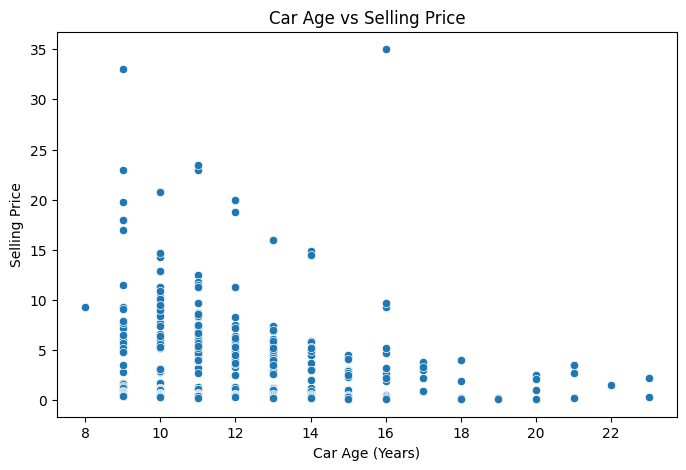

In [37]:
#car age vs selling price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price')
plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.show()

 both increased car age and higher kilometers driven generally lead to a decrease in selling price, while premium brands and certain models like the Corolla Altis, Ciaz, and Verna demonstrate superior resale value and higher average selling prices.

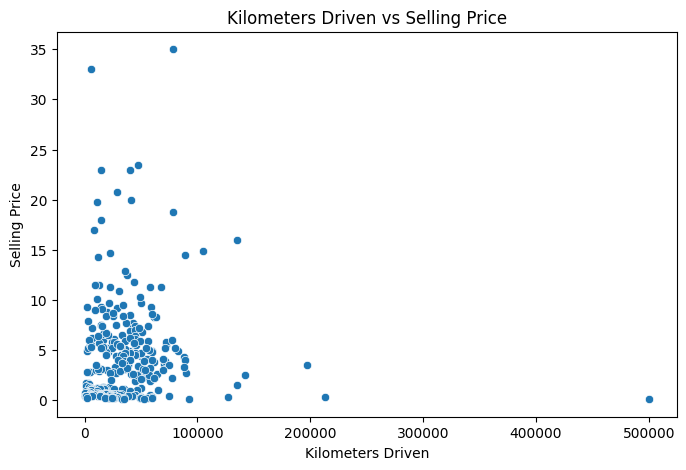

In [25]:
# km driven - sp of car
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price')
plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()

higher kilometers driven generally correlate with a decrease in the car's selling price, indicating depreciation due to usage.

In [26]:
df['Brand'] = df['Car_Name'].str.split().str[0]
brand_price = (
    df.groupby('Brand')['Selling_Price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
brand_price

,Selling_Price
Brand,
land,35.000000
fortuner,18.254000
innova,12.777778
creta,11.800000
elantra,11.600000
vitara,9.250000
ciaz,7.472222
city,7.419231
corolla,6.848824


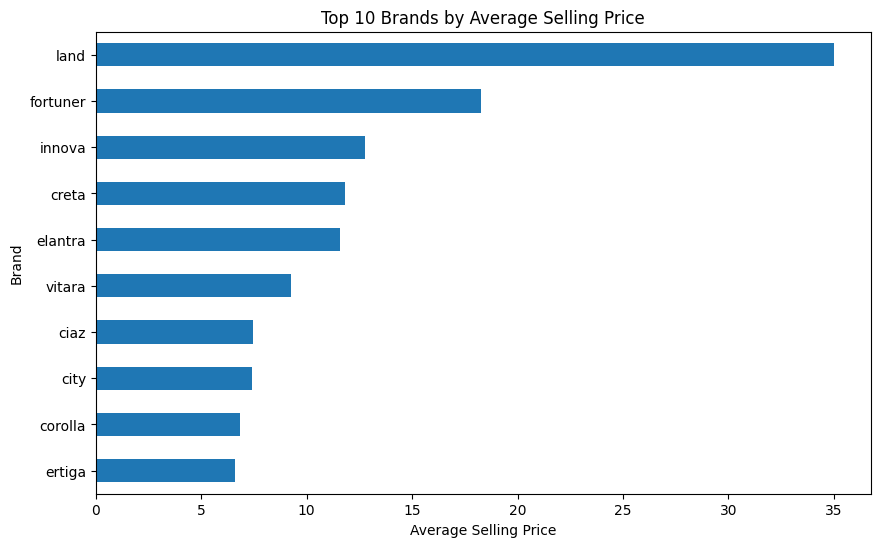

In [27]:
plt.figure(figsize=(10,6))
brand_price.sort_values().plot(kind='barh')
plt.title('Top 10 Brands by Average Selling Price')
plt.xlabel('Average Selling Price')
plt.ylabel('Brand')
plt.show()

The analysis shows that Land Rover has the highest average selling price at 35 lakh, followed by Fortuner and Innova, indicating stronger resale prices for premium and higher-end SUV models.

In [28]:
df['Price_Difference'] = (
    df['Present_Price'] - df['Selling_Price']
)
df['Resale_Value_%'] = (
    df['Selling_Price'] / df['Present_Price']
) * 100
df.nlargest(10, 'Resale_Value_%')[
    ['Car_Name', 'Present_Price', 'Selling_Price', 'Resale_Value_%']
]

,Car_Name,Present_Price,Selling_Price,Resale_Value_%
80,corolla altis,14.89,14.73,98.925453
8,ciaz,8.89,8.75,98.425197
231,verna,9.40,9.25,98.404255
208,i20,8.10,7.90,97.530864
235,verna,9.40,9.10,96.808511
234,grand i10,5.70,5.50,96.491228
250,creta,13.60,12.90,94.852941
126,Bajaj Avenger 220,0.95,0.90,94.736842
155,Honda Activa 4G,0.51,0.48,94.117647
5,vitara brezza,9.83,9.25,94.099695


The resale-value analysis shows that the Corolla Altis had the highest value retention at 98.93%, followed by the Ciaz and Verna, indicating strong resale performance among these cars.